In [35]:

import json
import pandas as pd
from wordcloud import WordCloud
from collective_synonyms import collective_synonyms


path = '/home/adrian.alvarez/Projects/diariodeleon-scraper/results/gpt4o_row_results/analisis_noticias.jsonl'
with open(path) as f:
    data = f.readlines()
# give a python dict
data = [json.loads(line) for line in data]


In [36]:
def create_variant_to_canonical_mapping(variants_dict):
    """
    Creates a reverse mapping from normalized variants to canonical names.
    """
    variant_to_canonical = {}
    for canonical_name, variants in variants_dict.items():
        # Normalize the canonical name
        normalized_canonical_name = canonical_name
        # Map the normalized canonical name to itself
        variant_to_canonical[normalized_canonical_name] = canonical_name
        # Map each normalized variant to the canonical name
        for variant in variants:
            normalized_variant = variant
            variant_to_canonical[normalized_variant] = canonical_name
    return variant_to_canonical

collective_synonyms = create_variant_to_canonical_mapping(collective_synonyms)

In [37]:
df = pd.DataFrame(data)
df.tail()

,url,title,subtitle,author,category,publication_date,updated_date,keywords,image,location,content,numero_protagonistas,numero_protagonistas_femeninos,numero_protagonistas_masculinos,numero_sujetos_secundarios,numero_sujetos_secundarios_femeninos,numero_sujetos_secundarios_masculinos,main_keywords,population_groups
8400,https://www.diariodeleon.es/ocio/destinos/2406...,"Astorga, ocio y deporte en las dos piscinas",Las instalaciones de verano mejoran con sombra...,A. Gaitero,Destinos,2024-06-25T20:49:31Z,2024-06-25T20:49:31Z,"[Astorga, Estadio La Eragudina, Medio ambiente...",https://imagenes.diariodeleon.es/files/article...,León,Las piscinas municipales de verano de Astorga ...,1,0,1,0,0,0,"piscinas, mantenimiento, ocio","vecinos, turistas"
8401,https://www.diariodeleon.es/opinion/240623/156...,Canto rodado: Sacri y los cuidados,N o sé qué habrá sido de Sacri. Hay personas q...,Ana Gaitero,Opinión,2024-06-23T01:30:00Z,2024-06-23T01:30:00Z,"[Discapacidad, ELA, Pensiones, Política, Villa...",https://imagenes.diariodeleon.es/files/article...,León,o sé qué habrá sido de Sacri. Hay personas que...,1,1,0,2,1,1,"cuidados, precariedad, política","personas mayores, personas migrantes"
8402,https://www.diariodeleon.es/leon/fiestas-san-j...,El Orgullo leonés se viste de fiesta y reivind...,"Moda, carrera de tacones, conciertos y la conm...",Ana Gaitero,Fiestas de San Juan y San Pedro,2024-06-19T19:07:19Z,2024-06-19T19:07:19Z,"[Día del Orgullo, León, LGTBI, Moda, Plaza de ...",https://imagenes.diariodeleon.es/files/article...,León,"San Juan, San Pedro y San Pelayo en el medio. ...",1,1,0,4,0,0,"reivindicación, celebración, derechos",comunidad LGTBIQ+
8403,https://www.diariodeleon.es/ocio/destinos/2406...,La casa de la luz,"Siete mil libros, fotografías y manuscritos, m...",Ana Gaitero,Destinos,2024-06-14T12:15:32Z,2024-06-14T12:15:32Z,"[La Bañeza, León, Libros, Poesía, Trabajo]",https://imagenes.diariodeleon.es/files/article...,León,la Casa de la Poesía de La Bañeza se accede po...,1,0,1,1,1,0,"poesía, legado, arte","escritores, poetas"
8404,https://www.diariodeleon.es/sociedad/mascotas/...,"Obi, la suave gatina de tres patas en busca de...",Obi es la gatita a la que se le pueden buscar ...,Ana Gaitero,Mascotas,2024-06-12T19:31:02Z,2024-06-12T19:31:02Z,"[Dietas, Vacunación]",https://imagenes.diariodeleon.es/files/article...,León,Obi es la gatita a la que se le pueden buscar ...,0,0,0,1,0,1,"adopción, rescate, felino",rescatistas de animales


In [38]:
df['population_groups']

0                                           
1                               paralímpicos
2                                           
3                                           
4                               agricultores
                        ...                 
8400                       vecinos, turistas
8401    personas mayores, personas migrantes
8402                       comunidad LGTBIQ+
8403                      escritores, poetas
8404                 rescatistas de animales
Name: population_groups, Length: 8405, dtype: object

In [39]:
def apply_synonims_pupulations(population_groups, collective_synonyms= collective_synonyms):
    population_groups = population_groups.lower()
    population_groups = [n.strip() for n in population_groups.split(',')]
    return ', '.join([collective_synonyms.get(population_group, population_group) for population_group in population_groups])

df['population_groups'] = df['population_groups'].apply(apply_synonims_pupulations)

In [40]:
all_populations = list()
for x in df['population_groups']:
    if x != '':
        temp = [n.strip().lower() for n in x.split(',')]
        
        all_populations += (temp)

In [41]:
from collections import Counter
counter = Counter(all_populations)

# Filter out elements with counts less than 5
filtered_counter = {key: count for key, count in counter.items() if count >= 2}

# Display the result
print(filtered_counter.keys())

dict_keys(['deportistas', 'agricultores', 'turistas', 'jóvenes', 'políticos', 'mujeres', 'herederos', 'migrantes', 'profesionales_deportivos', 'población_rural', 'ninguno', 'vecinos', 'conductores', 'prisioneros', 'pacientes', 'ciudadanos venezolanos', 'aficionados', 'cuerpos_de_seguridad', 'autoridades', 'religiosos', 'particulares', 'empresas', 'peatones', 'artesanos', 'niños_y_adolescentes', 'familias', 'niños', 'emprendedores', 'personas_sensibles', 'familia_real', 'artistas', 'comunidad_educativa', 'animalistas', 'profesionales_del_sector', 'independentistas catalanes', 'pescadores', 'militares_ucranianos', 'profesionales_de_la_salud', 'parejas', 'ciudadanos', 'celebridades', 'usuarios_de_redes_sociales', 'académicos', 'hogares', 'refugiados', 'palestina', 'habitantes rurales', 'empleados_públicos', 'pequeños municipios', 'eclesiásticos', 'trabajadores industriales', 'población_envejecida', 'hosteleros', 'municipios', 'feriantes', 'sociedad_civil', 'locales', 'familiares', 'corrup

In [42]:
df['gender_ratio_principales'] = df['numero_protagonistas_masculinos'] /(df['numero_protagonistas_masculinos'] + df['numero_protagonistas_femeninos'])

In [43]:
df['gender_ratio_secundario'] = df['numero_sujetos_secundarios_masculinos'] /(df['numero_sujetos_secundarios_masculinos'] + df['numero_sujetos_secundarios_femeninos'])

In [44]:
df2 = df[['gender_ratio_secundario', 'category', ]].groupby('category').count()

In [45]:
df['author'] = df['author'].str.lower()

In [46]:
group_df = df[['gender_ratio_secundario', 'category', 'gender_ratio_principales']].groupby('category').mean()

In [47]:
group_df['counts'] = df2['gender_ratio_secundario']

In [48]:
group_df = group_df[group_df['counts'] > 30]

In [49]:
group_df['gender_ratio_principales'] = group_df['gender_ratio_principales'] * 100
group_df['gender_ratio_secundario'] = group_df['gender_ratio_secundario'] * 100

# Reset index to turn 'category' into a column
group_df = group_df.reset_index()


In [50]:
group_df

,category,gender_ratio_secundario,gender_ratio_principales,counts
0,Castilla y León,88.041237,76.605030,195
1,Cultura,77.069181,72.440231,445
2,Deportes,88.154105,83.086863,820
3,Economía y empleo,85.634921,71.770833,84
4,El Bierzo,83.988864,76.537023,373
5,España,80.466940,73.308533,562
6,Gente y estilo,60.890731,47.910053,56
7,Internacional,84.597555,79.800928,300
8,León,84.682287,79.113171,579
9,Provincia,85.278426,74.702502,377


In [51]:

from collections import Counter
df['population_groups'] = df['population_groups'].fillna('')

# Step 2: Aggregate 'population_groups' per category
# Group by 'category' and concatenate 'population_groups' entries
pop_df = df.groupby('category')['population_groups'].apply(lambda x: ','.join(x)).reset_index()

# Step 3: Process the concatenated text per category
def get_top_words(text, N=10):
    # Split the text by commas
    words = text.split(',')
    # Remove whitespace and empty strings
    words = [word.strip() for word in words if word.strip()]
    # Count the frequency of each word
    word_counts = Counter(words)
    # Get the top N most common words
    top_words = word_counts.most_common(N)
    # Extract just the words
    top_words = [word for word, count in top_words]
    # Return as a comma-separated string
    return ', '.join(top_words)

# Apply the function to get top 10 words per category
pop_df['top_population_groups'] = pop_df['population_groups'].apply(get_top_words, N=5)

# Step 4: Merge the top words back into 'group_df'

# Keep only 'category' and 'top_population_groups' columns
pop_df = pop_df[['category', 'top_population_groups']]

# Merge with 'group_df' on 'category'
group_df = group_df.merge(pop_df, on='category', how='left')

# Now 'group_df' contains the top 10 population groups per category
# Display the updated 'group_df'
print(group_df)

             category  gender_ratio_secundario  gender_ratio_principales  \
0     Castilla y León                88.041237                 76.605030   
1             Cultura                77.069181                 72.440231   
2            Deportes                88.154105                 83.086863   
3   Economía y empleo                85.634921                 71.770833   
4           El Bierzo                83.988864                 76.537023   
5              España                80.466940                 73.308533   
6      Gente y estilo                60.890731                 47.910053   
7       Internacional                84.597555                 79.800928   
8                León                84.682287                 79.113171   
9           Provincia                85.278426                 74.702502   
10           Sociedad                67.238421                 59.538014   

    counts                              top_population_groups  
0      195     migrante

In [52]:
all_words_to_plot = set()
for words in group_df['top_population_groups']:
    word_list = [word.strip() for word in words.split(',')]
    all_words_to_plot.update(word_list)

# Convert the set to a list
all_words_to_plot = list(all_words_to_plot)

if 'científicos' not in all_words_to_plot:
   all_words_to_plot.append('científicos')
if 'lgtbi' not in all_words_to_plot:
   all_words_to_plot.append('lgtbi')
if 'refugiados' not in all_words_to_plot:
   all_words_to_plot.append('refugiados')

# avoid duplicated
all_words_to_plot = list(set(all_words_to_plot))


In [53]:
import ast

def convert_to_list(x):
    if isinstance(x, list):
        return x
    elif pd.isnull(x) or x == '':
        return []
    else:
        try:
            return ast.literal_eval(x)
        except:
            return [n.strip() for n in x.split(',')]

df['population_groups'] = df['population_groups'].apply(convert_to_list)

In [54]:
# Create an empty DataFrame to store percentages
import numpy as np
categories = group_df['category'].tolist()
percentage_df = pd.DataFrame(index=categories, columns=all_words_to_plot)
percentage_df = pd.DataFrame(
    data=0.0,  # Initialize all cells with 0.0
    index=categories,
    columns=all_words_to_plot,
    dtype=np.float64
)

# For each category, calculate the percentage of articles that contain each word
for category in categories:
    # Get the subset of df for this category
    df_cat = df[df['category'] == category]
    total_articles = len(df_cat)
    if total_articles == 0:
        continue
    for word in all_words_to_plot:
        # Count the number of articles that have this word in population_groups
        count = df_cat['population_groups'].apply(lambda x: word in x).sum()
        percentage = (count / total_articles) * 100
        percentage_df.loc[category, word] = percentage
percentage_df.head()

,familias,profesionales_deportivos,artistas,vecinos,palestina,comunidad_educativa,emprendedores,profesionales_del_sector,científicos,jóvenes,...,niños,refugiados,lgtbi,población_envejecida,mujeres,celebridades,independentistas,deportistas,clientes,familia_real
Castilla y León,3.271028,0.000000,0.000000,0.934579,0.000000,1.635514,1.869159,3.037383,1.635514,3.738318,...,3.504673,0.467290,0.467290,2.570093,3.037383,0.000000,0.0,0.000000,0.233645,0.000000
Cultura,0.809717,0.000000,12.145749,1.214575,0.269906,3.103914,0.134953,0.269906,3.913630,3.778677,...,0.269906,0.404858,0.269906,0.539811,2.699055,0.404858,0.0,0.000000,0.134953,0.000000
Deportes,0.162999,21.760391,0.000000,0.325998,0.000000,0.081500,0.162999,0.000000,0.000000,2.281989,...,0.733496,0.000000,0.000000,0.162999,2.118989,0.000000,0.0,20.945395,0.000000,0.000000
Economía y empleo,5.384615,0.000000,0.000000,0.384615,0.000000,0.384615,5.384615,13.461538,0.769231,2.307692,...,0.384615,0.000000,0.384615,0.769231,0.769231,0.000000,0.0,0.000000,6.923077,0.000000
El Bierzo,1.932367,0.241546,1.690821,7.246377,0.000000,3.381643,1.207729,2.415459,1.086957,3.381643,...,1.086957,0.000000,0.241546,2.053140,0.966184,0.000000,0.0,0.120773,0.603865,0.120773


In [55]:
percentage_df.columns

Index(['familias', 'profesionales_deportivos', 'artistas', 'vecinos',
       'palestina', 'comunidad_educativa', 'emprendedores',
       'profesionales_del_sector', 'científicos', 'jóvenes', 'agricultores',
       'sindicatos', 'migrantes', 'civiles', 'políticos', 'turistas',
       'autoridades_judiciales', 'niños_y_adolescentes', 'aficionados',
       'artesanos', 'niños', 'refugiados', 'lgtbi', 'población_envejecida',
       'mujeres', 'celebridades', 'independentistas', 'deportistas',
       'clientes', 'familia_real'],
      dtype='object')

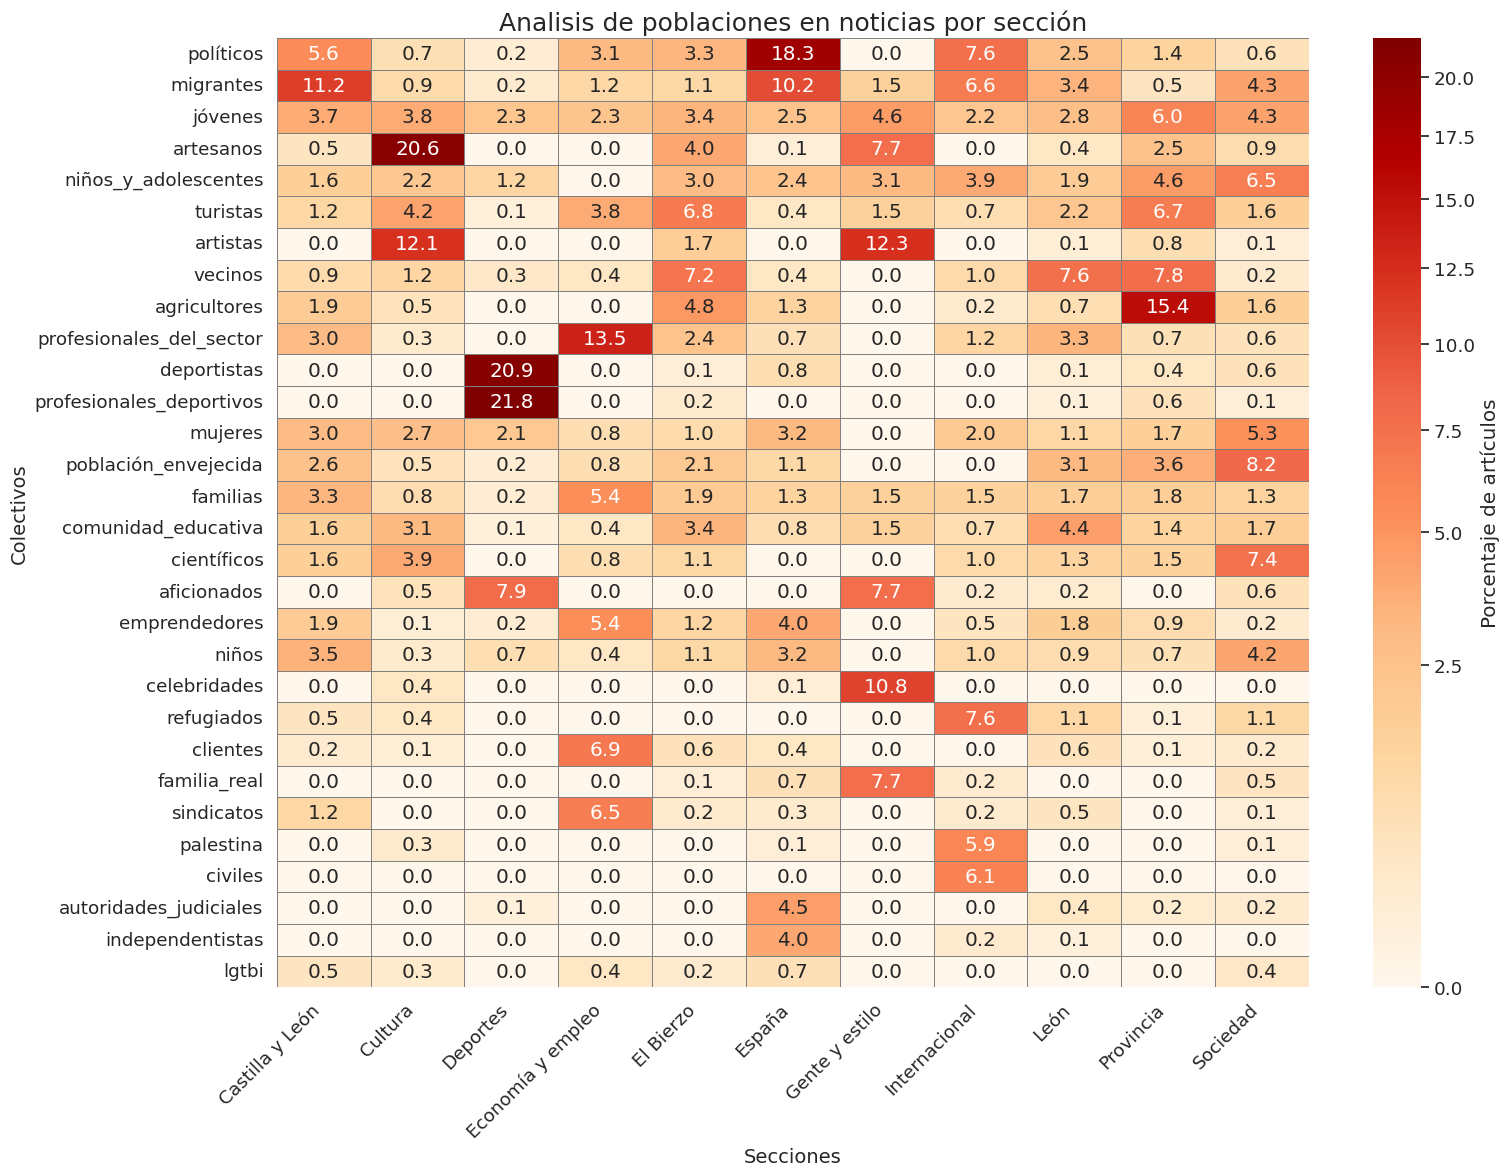

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

# Assuming 'percentage_df' is the DataFrame with percentages calculated earlier

# Reset index to make 'category' a column if it's not already
percentage_df = percentage_df.reset_index()

# Transform the DataFrame to have 'word' as rows and 'category' as columns
percentage_long_df = percentage_df.melt(id_vars='index', var_name='word', value_name='percentage')
heatmap_data = percentage_long_df.pivot(index='word', columns='index', values='percentage')

# Sort the words based on the average percentage across categories (optional)
heatmap_data['mean_percentage'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('mean_percentage', ascending=False)
heatmap_data = heatmap_data.drop('mean_percentage', axis=1)

# Create the heatmap
plt.figure(figsize=(16, 12))
sns.set(style="white", font_scale=1.2)  # Increase font size for better readability

# Define a custom colormap without yellow
cmap = sns.color_palette("OrRd", as_cmap=True)

# Adjust the color scaling to be more sensitive to changes above 1%
norm = PowerNorm(gamma=0.5)  # gamma < 1 makes lower values more distinguishable

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=cmap,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Porcentaje de artículos'},
    square=False,
    norm=norm
)

# Customize the plot
plt.title("Analisis de poblaciones en noticias por sección", fontsize=18)
plt.xlabel("Secciones", fontsize=14)
plt.ylabel("Colectivos", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

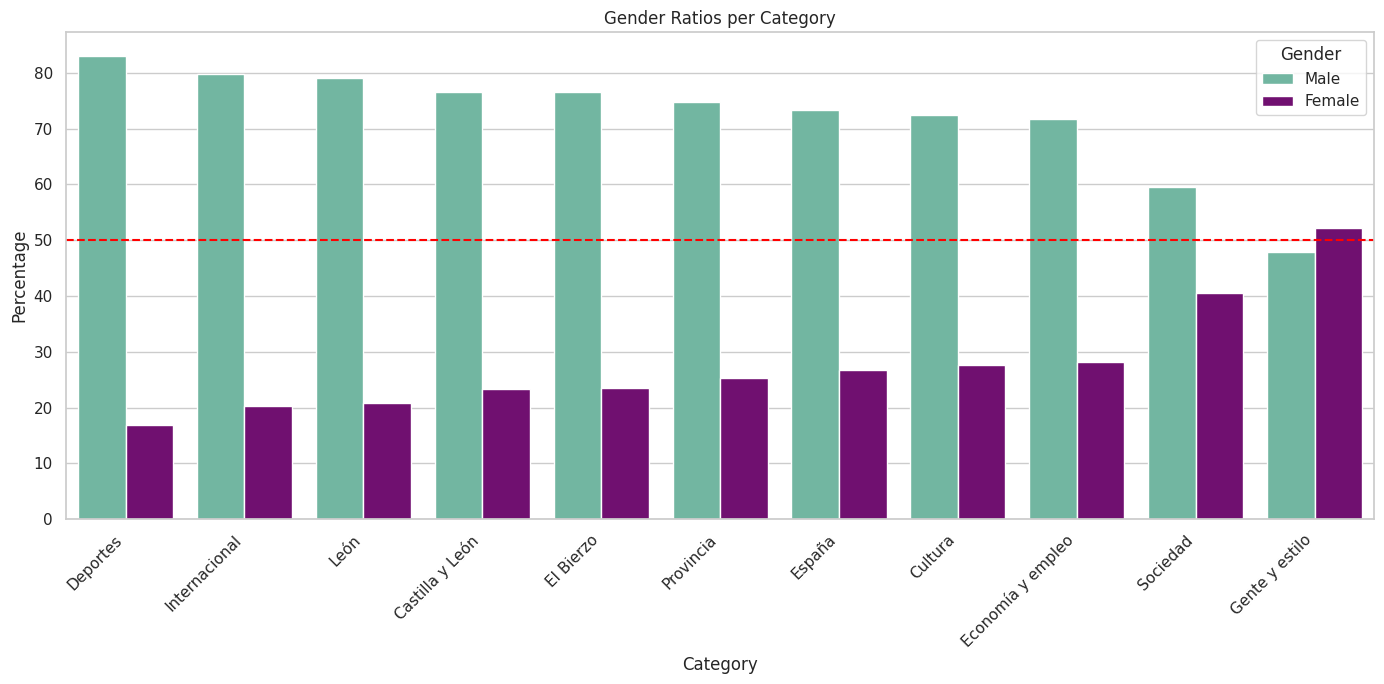

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Step 1.5: Order the DataFrame based on the male proportion
group_df = group_df.sort_values(by='gender_ratio_principales', ascending=False)

# Step 2: Prepare data for plotting
data = []
for idx, row in group_df.iterrows():
    category = row['category']
    male_percentage = row['gender_ratio_principales']
    female_percentage = 100 - male_percentage
    data.append({'Category': category, 'Gender': 'Male', 'Percentage': male_percentage})
    data.append({'Category': category, 'Gender': 'Female', 'Percentage': female_percentage})

plot_df = pd.DataFrame(data)

# Ensure the categories are in the correct order
plot_df['Category'] = pd.Categorical(plot_df['Category'], categories=group_df['category'], ordered=True)

# Step 3: Plot the data
plt.figure(figsize=(14, 7))
sns.set(style="whitegrid")

# Change the color of female bars to purple
palette = {'Male': sns.color_palette("Set2")[0], 'Female': 'purple'}

# Create the bar plot
sns.barplot(x='Category', y='Percentage', hue='Gender', data=plot_df, palette=palette)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add title and labels
plt.title('Gender Ratios per Category')
plt.xlabel('Category')
plt.ylabel('Percentage')

# Draw a red dashed line at 50%
plt.axhline(50, color='red', linestyle='--')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [58]:
author_df = df[['gender_ratio_secundario', 'author', 'gender_ratio_principales']].groupby(['author']).mean()
count_df = df[['gender_ratio_secundario', 'author']].groupby('author').count()

In [59]:
author_df['counts'] = count_df['gender_ratio_secundario']

In [60]:
author_df[author_df['counts'] > 5]

,gender_ratio_secundario,gender_ratio_principales,counts
author,,,
a. calvo,0.872549,0.788333,17
abigail calvo,0.908333,0.752564,8
acacio díaz,0.559524,0.571429,6
agencias,0.799587,0.746479,774
alba mieres,0.708333,0.758333,12
...,...,...,...
verónica viñas,0.795661,0.734229,117
álvaro caballero,0.908530,0.889196,117
álvaro quiñones,0.576628,0.561299,10


In [61]:
df['keywords']

0       [Corros, Liga de Verano, Lucha leonesa, Trofeo...
1                                                      []
2                                          [Ademar, León]
3       [Cultural y Deportiva Leonesa, León, SD Ponfer...
4        [ASAJA, Bocyl, Castilla y León, DO Bierzo, León]
                              ...                        
8400    [Astorga, Estadio La Eragudina, Medio ambiente...
8401    [Discapacidad, ELA, Pensiones, Política, Villa...
8402    [Día del Orgullo, León, LGTBI, Moda, Plaza de ...
8403           [La Bañeza, León, Libros, Poesía, Trabajo]
8404                                 [Dietas, Vacunación]
Name: keywords, Length: 8405, dtype: object

In [62]:
import ast
import matplotlib.pyplot as plt

# Step 2: Explode the 'keywords' column
df_exploded = df.explode('keywords')
df_exploded = df_exploded[df_exploded['keywords'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold keywords per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['keywords'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


/tmp/ipykernel_158965/454221480.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_exploded.fillna('', inplace=True)


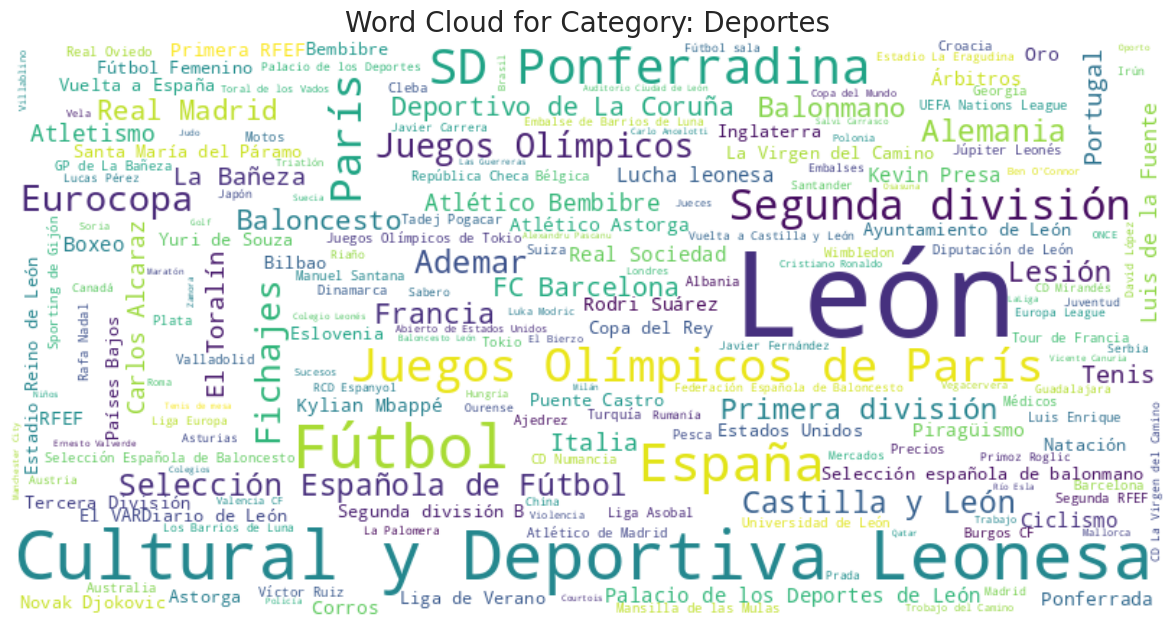

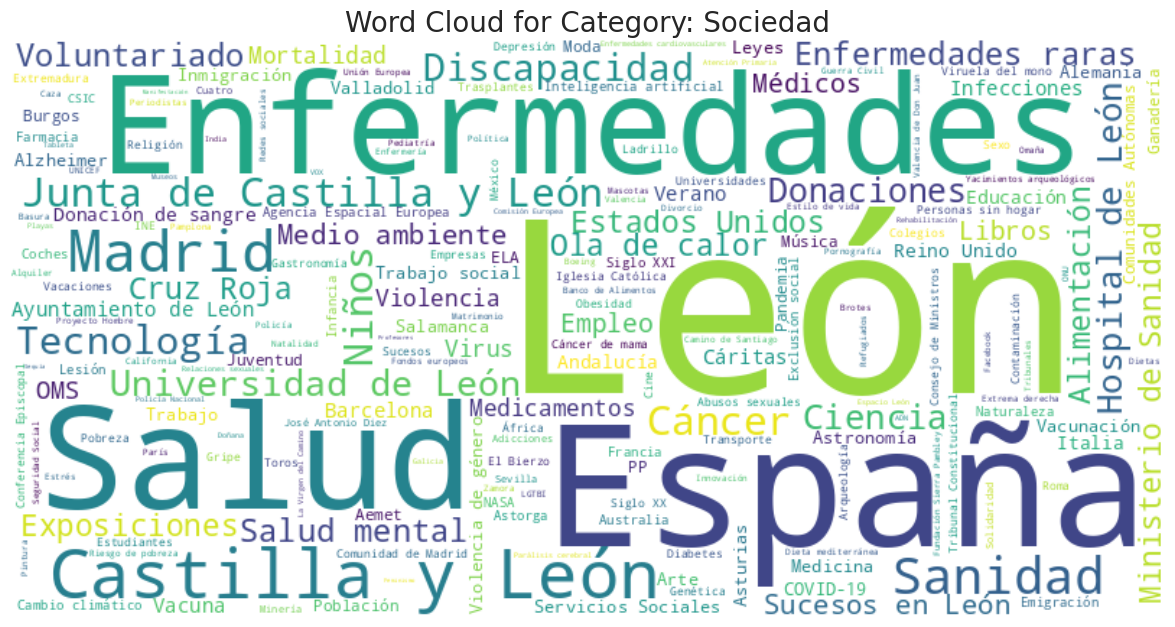

In [63]:
# Define a function to generate word clouds from frequencies
def generate_wordcloud_from_frequencies(frequencies, category_name):
    # Create a word cloud object
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(frequencies)
    
    # Display the generated image
    plt.figure(figsize=(15, 7.5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Category: {category_name.capitalize()}', fontsize=20)
    plt.show()

# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [64]:
df.head()

,url,title,subtitle,author,category,publication_date,updated_date,keywords,image,location,...,numero_protagonistas,numero_protagonistas_femeninos,numero_protagonistas_masculinos,numero_sujetos_secundarios,numero_sujetos_secundarios_femeninos,numero_sujetos_secundarios_masculinos,main_keywords,population_groups,gender_ratio_principales,gender_ratio_secundario
0,https://www.diariodeleon.es/deportes/240830/16...,Lucha leonesa: Valencia de Don Juan acoge hoy ...,La localidad leonesa de Valencia de Don Juan d...,redacción,Deportes,2024-08-30T21:40:09Z,2024-08-30T21:40:09Z,"[Corros, Liga de Verano, Lucha leonesa, Trofeo...",https://imagenes.diariodeleon.es/files/article...,León,...,0,0,0,0,0,0,"deporte, evento, tradición",[],NaN,NaN
1,https://www.diariodeleon.es/deportes/240830/16...,"Paralímpicos: Sara Aller, eliminada en competi...",La leonesa Sara Aller acumuló su tercera derro...,redacción,Deportes,2024-08-30T21:39:48Z,2024-08-30T21:39:48Z,[],https://imagenes.diariodeleon.es/files/article...,León,...,2,2,0,0,0,0,"boccia, derrota, competición",[deportistas],0.0,NaN
2,https://www.diariodeleon.es/deportes/240830/16...,El Ademar va a dar el golpe,Dani Gordo cree que su equipo llega preparado ...,pablo rioja,Deportes,2024-08-30T21:39:06Z,2024-08-30T21:39:06Z,"[Ademar, León]",https://imagenes.diariodeleon.es/files/article...,León,...,1,0,1,0,0,0,"deporte, competición, eliminatoria",[],1.0,NaN
3,https://www.diariodeleon.es/deportes/240830/16...,La Cultural ficha a Chacón antes de medirse al...,El equipo leonés se estrena a domicilio El ext...,ángel fraguas,Deportes,2024-08-30T21:38:27Z,2024-08-30T21:38:27Z,"[Cultural y Deportiva Leonesa, León, SD Ponfer...",https://imagenes.diariodeleon.es/files/article...,León,...,3,0,3,1,0,1,"fútbol, fichajes, cesión",[],1.0,1.0
4,https://www.diariodeleon.es/bierzo/240830/1606...,Vinicultura: Asaja pide a la DO Bierzo que com...,El Bocyl publica que resolución que autoriza e...,redacción,El Bierzo,2024-08-30T20:49:34Z,2024-08-30T20:49:34Z,"[ASAJA, Bocyl, Castilla y León, DO Bierzo, León]",https://imagenes.diariodeleon.es/files/article...,Ponferrada,...,4,0,0,0,0,0,"vinicultura, regulación, uva",[agricultores],NaN,NaN


In [65]:
group_df

,category,gender_ratio_secundario,gender_ratio_principales,counts,top_population_groups
2,Deportes,88.154105,83.086863,820,"profesionales_deportivos, deportistas, aficion..."
7,Internacional,84.597555,79.800928,300,"refugiados, políticos, migrantes, civiles, pal..."
8,León,84.682287,79.113171,579,"vecinos, comunidad_educativa, migrantes, profe..."
0,Castilla y León,88.041237,76.605030,195,"migrantes, políticos, jóvenes, niños, familias"
4,El Bierzo,83.988864,76.537023,373,"vecinos, turistas, agricultores, artesanos, jó..."
9,Provincia,85.278426,74.702502,377,"agricultores, vecinos, turistas, jóvenes, niño..."
5,España,80.466940,73.308533,562,"políticos, migrantes, autoridades_judiciales, ..."
1,Cultura,77.069181,72.440231,445,"artesanos, artistas, científicos, turistas, jó..."
3,Economía y empleo,85.634921,71.770833,84,"profesionales_del_sector, clientes, sindicatos..."
10,Sociedad,67.238421,59.538014,401,"población_envejecida, científicos, niños_y_ado..."


In [66]:
import ast
import matplotlib.pyplot as plt
df['main_keywords'] = df['main_keywords'].apply(lambda x: x.split(',') if x else [])
# Step 2: Explode the 'keywords' column
df_exploded = df.explode('main_keywords')
df_exploded = df_exploded[df_exploded['main_keywords'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold main_keywords per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['main_keywords'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


/tmp/ipykernel_158965/2911421574.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_exploded.fillna('', inplace=True)


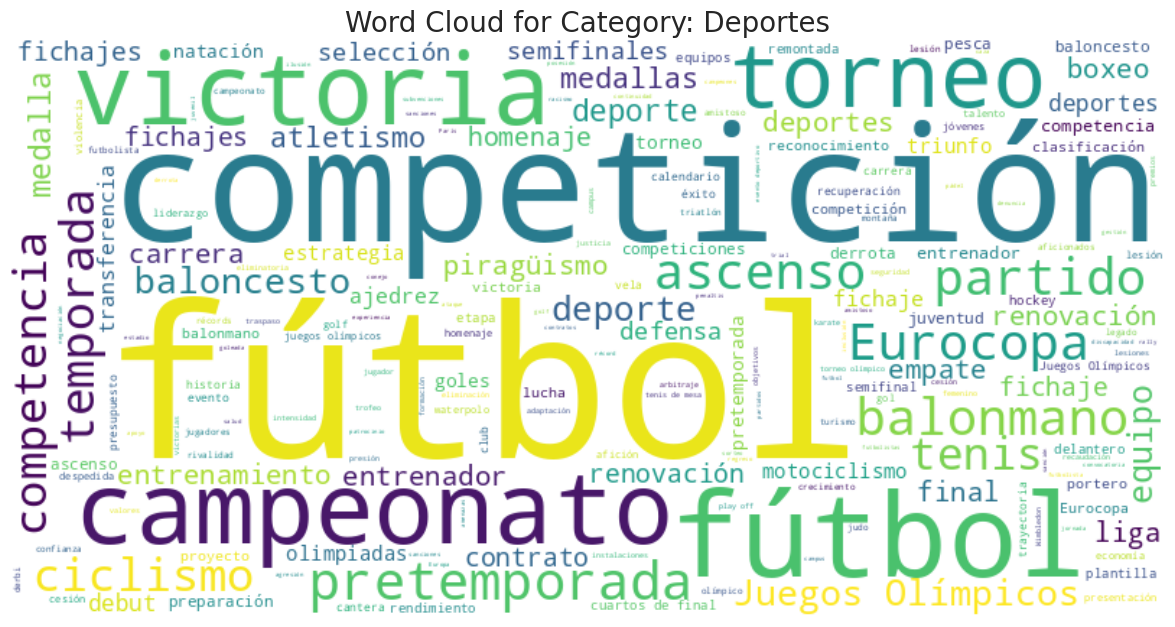

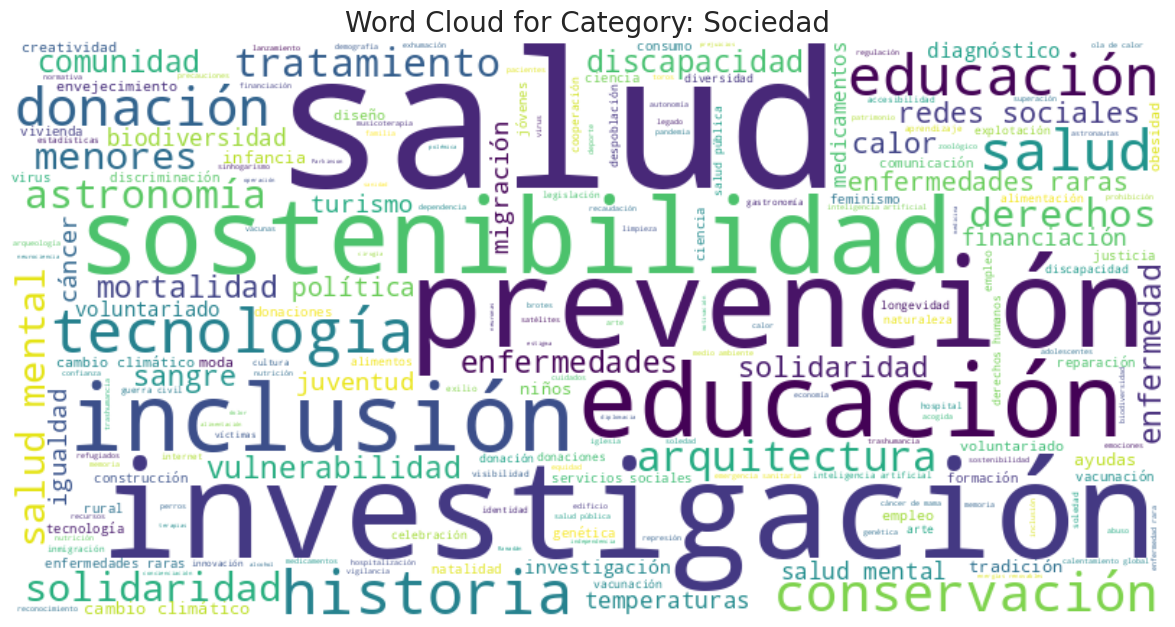

In [67]:
# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [68]:
import ast
import matplotlib.pyplot as plt
# Step 2: Explode the 'keywords' column
df['population_groups'] = df['population_groups'].apply(lambda x: x.split(',') if x else [])
df_exploded = df.explode('population_groups')
df_exploded = df_exploded[df_exploded['population_groups'] != '']  # Remove empty strings

df_exploded['category'] = df_exploded['category']
df_exploded.fillna('', inplace=True)
# Categories we're interested in
categories = ['Deportes', 'Sociedad']

# Initialize a dictionary to hold population_groups per category

# Initialize a dictionary to hold keyword frequencies per category
category_keyword_freq = {}

for category in categories:
    # Filter the DataFrame for the current category
    df_category = df_exploded[df_exploded['category'] == category]
    
    # Calculate the frequency of each keyword
    keyword_freq = df_category['population_groups'].value_counts().to_dict()
    
    # Store in the dictionary
    category_keyword_freq[category] = keyword_freq


AttributeError: 'list' object has no attribute 'split'

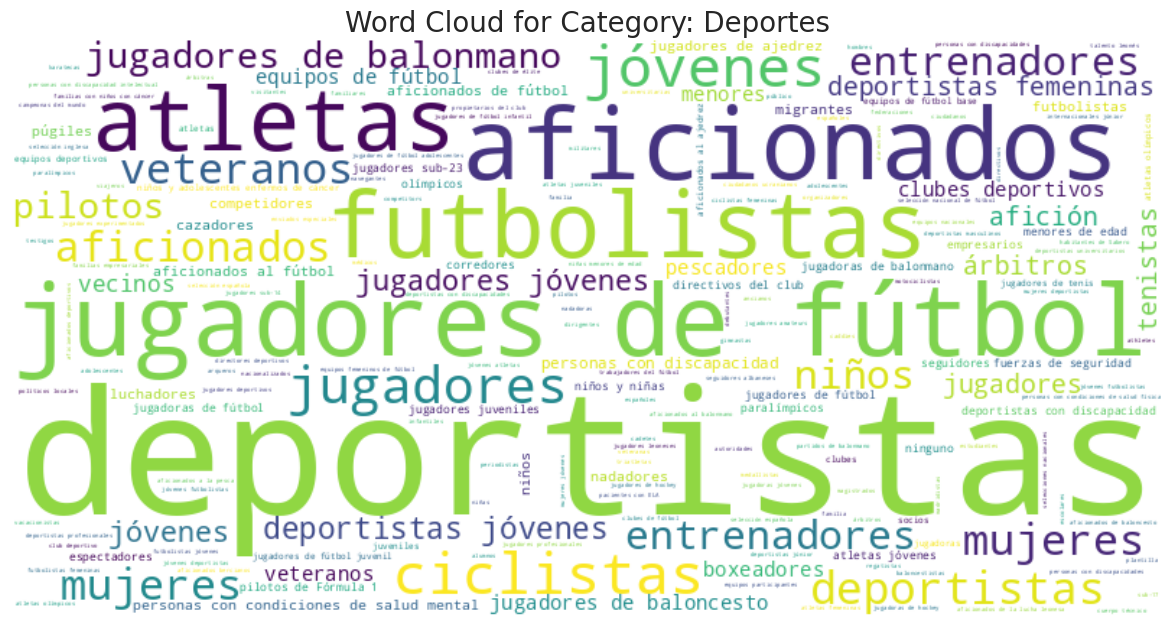

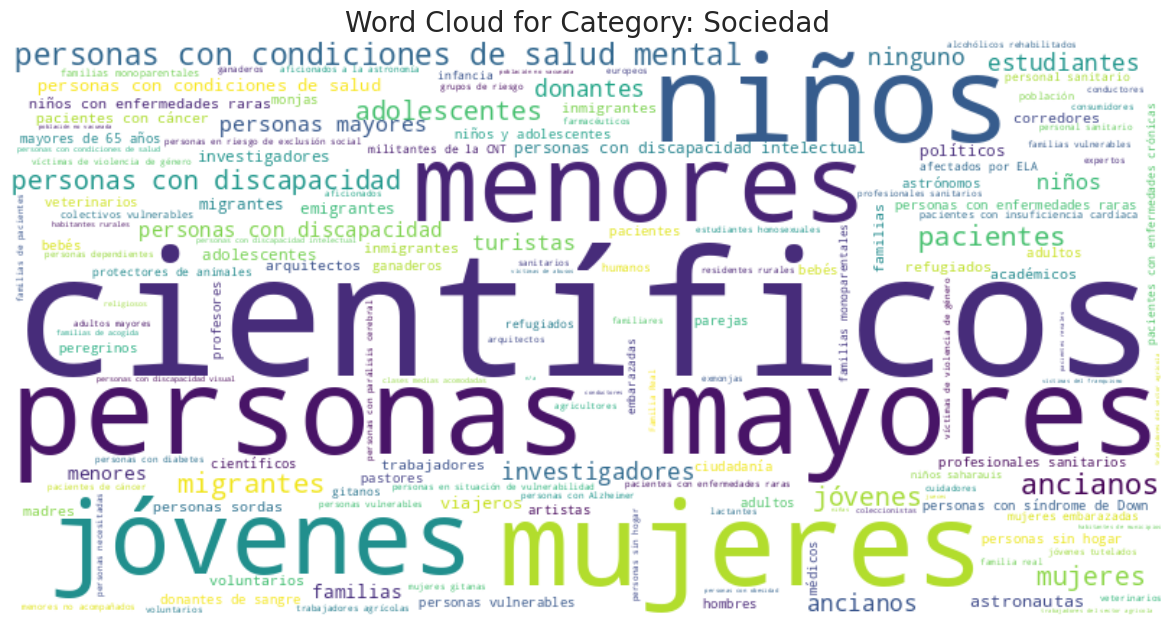

In [ ]:
# Generate word clouds for each category
for category, freq_dict in category_keyword_freq.items():
    if freq_dict:  # Check if there are any keywords to generate a word cloud
        generate_wordcloud_from_frequencies(freq_dict, category)
    else:
        print(f"No keywords found for category '{category}'.")

In [ ]:
df.to_excel('analisis_noticias.xlsx')

In [ ]:
!pip install openpyxl


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
author_df.to_excel('analisis_noticias_por_autor.xlsx')